# Assignment 1: Question 2
**Course:** Machine Learning  
**Student:** Navneet Das  
**Date:** july 2026  

---

## Polynomial Regression — Choosing the Right Degree (Bias-Variance Tradeoff)

### Objective
> polynomial regression models of varying degrees to a position-salary dataset and study overfitting/underfitting.

step 1: Load the dataset from position_salaries.csv.

In [1]:
import pandas as pd
data = pd.read_csv("./Data/Position_Salaries.csv",usecols=["Level","Salary"])
data.shape,data.tail()

((10, 2),
    Level   Salary
 5      6   150000
 6      7   200000
 7      8   300000
 8      9   500000
 9     10  1000000)

step 2: Fit polynomial regression models for degrees 1, 2, 4, and 8.

In [2]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

trained_models={}
for degree in [1,2,4,8]:
    model_pipeline = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )
    model_pipeline.fit(data[["Level"]],data["Salary"])
    print(f"model with degree {degree} trained")
    trained_models[degree]=model_pipeline
    print(f"model saved!")
    print("\n\n","_"*30)

model with degree 1 trained
model saved!


 ______________________________
model with degree 2 trained
model saved!


 ______________________________
model with degree 4 trained
model saved!


 ______________________________
model with degree 8 trained
model saved!


 ______________________________


step 3: For each degree, compute the R² score / MSE on training data.

In [39]:
from sklearn.metrics import mean_squared_error, r2_score
mse={}
r2={}
for model in trained_models:
    # print(trained_models[model].named_steps["linearregression"].coef_)
    mse[model]=mean_squared_error(data["Salary"],trained_models[model].predict(data[["Level"]]))
    r2[model]=r2_score(data["Salary"],trained_models[model].predict(data[["Level"]]))

# displaying the MSE and r2
print("model\t| R2\t\t| mean_squared_error" )
for degree in trained_models:
    print(f"{degree}\t| {r2[degree]:.4f}\t| {mse[degree]:.4f}")
    print(f"{"-"*8}|{"-"*15}|{"-"*20}")

model	| R2		| mean_squared_error
1	| 0.6690	| 26695878787.8788
--------|---------------|--------------------
2	| 0.9162	| 6758833333.3333
--------|---------------|--------------------
4	| 0.9974	| 210343822.8438
--------|---------------|--------------------
8	| 1.0000	| 524526.9436
--------|---------------|--------------------


step 4: Plot all fitted curves on the same graph and visually compare underfitting vs. overfitting.

In [60]:
import warnings
warnings.filterwarnings("ignore")

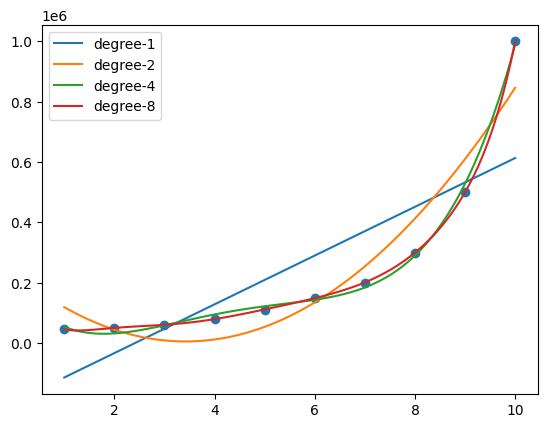

In [62]:
import matplotlib.pyplot as plt
import numpy as np

x_smooth = np.linspace(data[["Level"]].min(),data[["Level"]].max(),100)

plt.scatter(data["Level"],data["Salary"])
for degree in trained_models:
    y_smooth=trained_models[degree].predict(pd.DataFrame(x_smooth))
    plt.plot(x_smooth,y_smooth,label=f"degree-{degree}")
plt.legend()
plt.show()


|models with degree|fit|
|------------------|---|
|1|underfitting|
|2|best fitting|
|4|best fitting|
|8|overfitting|
#### Heance: we can say that the degree 4 has the best fit

step 5: Predict the salary for Level = 6.5 using the best-performing model.

In [71]:
predicted_salary = trained_models[4].predict([[6.5]])
print(f"the predicted salary of a person having a experiance of 6.5years will be {predicted_salary[0]:.3f}")

the predicted salary of a person having a experiance of 6.5years will be 158862.453


step 6: Discuss which degree gives the best trade-off between bias and variance.

**Degree 4 gives the best trade-off between bias and variance.**  
1. Degree 1: High Bias (Underfitting)  
2. Degree 2: Moderate Bias  
3. Degree 4: Best Trade-off (Optimal Fit)
4. Degree 8: High Variance (Overfitting)